Analysis into if cmems is more accurate based off of the initial abbility to predict the the dFADs speeds

- Start by using compairson of CMEMs and the dFADs speeds at current time 
    Produce plot of inital cmems speed errors vs leadtime errors. 
    create a list of all the innital speed errors 


In [64]:
import numpy as np 
import pandas as pd 
import geopandas as gpd
from importlib import reload
import functions.funcs as funcs 
reload(funcs)
import matplotlib.pyplot as plt

In [65]:
ds = gpd.read_parquet(r"Data\MappedOSCAR_SAT_MI_Cleanedspeeds.parquet") 
ds = funcs.querry_date_range(ds, pd.Timestamp("2024-1-1"), pd.Timestamp("2025-1-1"))
ds = ds.reset_index(drop = True)
fc = pd.read_csv("Parcels/saved_output/combined_cmems2024.csv")
fc1 = pd.read_csv("Parcels/saved_output/OSCAR_2024v2.csv")

fc2 = pd.read_csv("Parcels/saved_output/optimal_cmems_OSCAR_2024.csv")
fc3 = pd.read_csv("Parcels/saved_output/No_forecast.csv")
fc["Time"] = pd.to_datetime(fc["Time"])
fc['error_km'] = funcs.haversine_df(fc, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
fc1["Time"] = pd.to_datetime(fc1["Time"])
fc1['error_km'] = funcs.haversine_df(fc1, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
fc2["Time"] = pd.to_datetime(fc2["Time"])
fc2["error_km"] = funcs.haversine_df(fc2, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
fc3["Time"] = pd.to_datetime(fc3["Time"])
fc3["error_km"] = funcs.haversine_df(fc3, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
ds.columns

Index(['index', 'BuoyName', 'MinOfDate', 'MaxOfDate', 'TimeStamp', 'geometry',
       'x_deg', 'y_deg', 'x_km', 'y_km', 'xy_km', 'Delta_Timestamps',
       'x_speed', 'y_speed', 'xy_speed', 'points_removed', 'Masked_array',
       'points_removed2', 'Masked_array2', 'Masked_array_combined', 'mapped_v',
       'mapped_u', 'mapped_v_oscar', 'mapped_u_oscar'],
      dtype='str')

In [66]:

print(fc1.columns)

Index(['Unnamed: 0', 'BuoyID', 'Time', 'lat_true', 'lon_true', 'lat_forcast',
       'lon_forcast', 'leadtime', 'error_km'],
      dtype='str')


In [67]:
fc2.query("leadtime == 0").shape

(8429, 11)

In [68]:
def add_starttime(fc):
    fc["starttime"] = (fc["Time"] - pd.to_timedelta(fc["leadtime"], unit= "hours")).dt.round("min")
    return fc

In [69]:
longlist = pd.DataFrame({})
longlist["Time"] = funcs.Column_to_List(ds, "TimeStamp", idlist = False)
longlist["lats"], longlist["lons"] = funcs.list_of_latlon(ds, False)
longlist["x_speed"] = funcs.Column_to_List(ds, "x_speed", idlist = False)
longlist["y_speed"] = funcs.Column_to_List(ds, "y_speed", idlist = False)
longlist["v_mapped"], longlist["BuoyID"]  =funcs.Column_to_List(ds, "mapped_v", idlist = True)
longlist["v_mapped_OSCAR"], longlist["BuoyID"]  =funcs.Column_to_List(ds, "mapped_v_oscar", idlist = True)
longlist["u_mapped"] = funcs.Column_to_List(ds, "mapped_u", idlist = False)
longlist["u_mapped_OSCAR"] = funcs.Column_to_List(ds, "mapped_u_oscar", idlist = False)
longlist.Time = pd.to_datetime(longlist.Time)
mask = (longlist.Time > pd.Timestamp('2023-12-31')) 
longlist = longlist[mask].reset_index(drop = True)
longlist = longlist[longlist.Time < pd.Timestamp('2025-1-1')].reset_index(drop = True)

In [70]:
## maps the True dFAD dFADs speeds onto 
def merge_forecast_true(fc, longlist):
    merged = pd.merge_asof(
    fc.sort_values('Time'),
    longlist.sort_values('Time'),
    on='Time',
    by='BuoyID',
    tolerance=pd.Timedelta(minutes=1),
    direction='nearest'
    )
    return merged

merged = merge_forecast_true(fc, longlist)
merged["speed"] = np.sqrt(merged.x_speed**2 + merged.y_speed**2)
merged["starttime"] = (merged.Time - pd.to_timedelta(merged.leadtime, "hours")).dt.round('min')
merged = merged.sort_values('leadtime') ## was time not sure if this changes results in later analysis
merged["initial_speed"] = merged.groupby(by=["BuoyID", "starttime"])['speed'].transform('first')
## plot for just 24 hours 
bins = np.linspace(0,8*24,2*24+1)
merged["lead_bins"] = pd.cut(merged["leadtime"], bins)
binlist = merged["lead_bins"].unique()
a  =binlist[7] ## list of bin intervals 
print(a)
mergedhr = merged.groupby("lead_bins").get_group(a)
##now group by speeds and take a mean.
speedbins = np.linspace(0,mergedhr.initial_speed.max(),25 )
mergedhr["speed_bin"] = pd.cut(mergedhr["initial_speed"], speedbins)
binned_errors = mergedhr.groupby("speed_bin")["error_km"].mean()

(24.0, 28.0]


### Speed Corrilations with errors.

In [71]:
def inital_speed_binning(merged: pd.DataFrame, binindex : int):
    bins = np.linspace(0,8*24,2*24+1)
    merged["lead_bins"] = pd.cut(merged["leadtime"], bins)
    binlist = merged["lead_bins"].unique()
    a  =binlist[binindex] ## list of bin intervals 
    print(a)
    mergedhr = merged.groupby("lead_bins").get_group(a)
    ##now group by speeds and take a mean.
    speedbins = np.linspace(0,mergedhr.initial_speed.max(),25)
    mergedhr["speed_bin"] = pd.cut(mergedhr["initial_speed"], speedbins)
    binned_errors = mergedhr.groupby("speed_bin")["error_km"].mean()
    return speedbins, binned_errors

speedbins, binned_errors = inital_speed_binning(merged,8)

(28.0, 32.0]


(0.0, 4.0]
(4.0, 8.0]
(8.0, 12.0]
(12.0, 16.0]
(16.0, 20.0]
(20.0, 24.0]
(24.0, 28.0]
(28.0, 32.0]
(32.0, 36.0]
(36.0, 40.0]


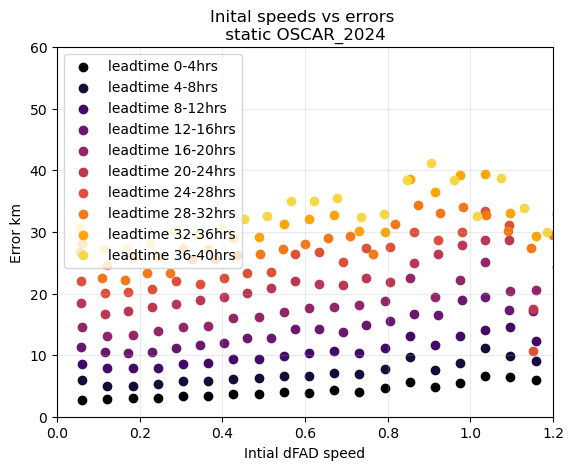

In [72]:
fig, ax = plt.subplots()
cmap = plt.cm.inferno
for i in range(10):
    speedbins, binned_errors = inital_speed_binning(merged,i+1)
    ax.scatter(speedbins[1:], binned_errors, label=f"leadtime {i*4}-{(i+1)*4}hrs", color=cmap(i/10))
ax.set_ylabel("Error km")
ax.set_xlabel("Intial dFAD speed")
ax.set_xlim(0,1.2)
ax.set_ylim(0,60)
ax.set_title("Inital speeds vs errors \n static OSCAR_2024 ")
ax.grid(alpha = 0.25)
ax.legend()

### analyzing optimal forecasting dataset

In [73]:
### plot simple time series of Percent cmems or OSCAR

fc2i= fc2.query("leadtime == 0").reset_index(drop = True).sort_values("Time")
fc2i["Day"] = fc2i.Time.dt.date
print(f"Fraction of cmems forecasts : {fc2i.query("model == 'cmems'")["model"].count()/fc2i.model.count() :0.4}")

percentcmems = fc2i.groupby("Day").apply(lambda x: (x["model"] == "cmems").sum() / len(x) * 100)
percentcmems = percentcmems.to_frame().rename(columns = {0: "cmems"})
percentcmems["rolling"] = percentcmems.cmems.rolling(7).mean()

Fraction of cmems forecasts : 0.3105


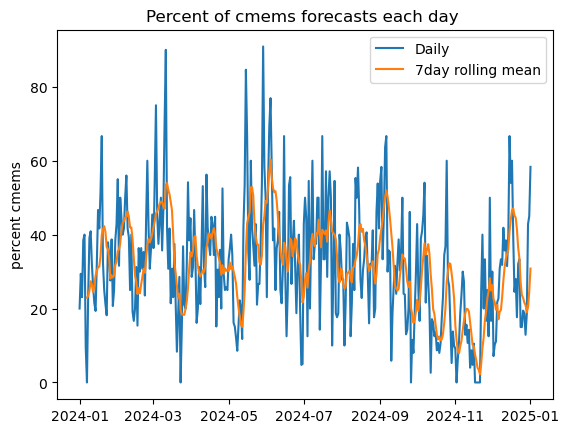

In [74]:
fig, ax = plt.subplots()
ax.plot(percentcmems.index, percentcmems.values, label = ["Daily", "7day rolling mean"])
ax.set_ylabel("percent cmems")
ax.set_title("Percent of cmems forecasts each day ")
ax.legend()

In [75]:
### merging forecast data with mapped speeds
oscar = fc2.query("model == 'OSCAR'").reset_index(drop = True)
oscar_merged = merge_forecast_true(oscar, longlist)
oscar_merged = oscar_merged.rename(columns= {"u_mapped_OSCAR" : "u_mapped_comb", "v_mapped_OSCAR": "v_mapped_comb"})

cmems = fc2.query("model =='cmems'").reset_index(drop = True)
cmems_merged = merge_forecast_true(cmems, longlist)
cmems_merged = cmems_merged.rename(columns= {"u_mapped" : "u_mapped_comb", "v_mapped": "v_mapped_comb"})
fc_opt = pd.concat([cmems_merged, oscar_merged])

In [76]:
fc_opt["projection"] = (fc_opt.y_speed * fc_opt.v_mapped_comb)+ (fc_opt.x_speed * fc_opt.u_mapped_comb)
fc_opt["projection"]  = fc_opt["projection"]/(fc_opt.x_speed**2 +fc_opt.y_speed**2 )**(1/2)
fc_opt["initial_angle"] = fc_opt["projection"]/(fc_opt.u_mapped_comb**2 +fc_opt.v_mapped_comb**2 )**(1/2)
fc_opt["initial_angle"] = np.arccos(fc_opt["initial_angle"])*180/np.pi
fc_opt_saved = fc_opt.copy()

### Projection of dFAD onto the model speeds vs errors. 


In [ ]:
def calc_projection_initial_angle(merged, sufix = None):
    projection = "projection"
    angle = "angle"
    u = "u_mapped"
    v = "v_mapped"
    if sufix is not None:
        projection +=sufix
        angle +=sufix
        u += sufix
        v+= sufix 
    merged[projection] = (merged.y_speed * merged[v])+ (merged.x_speed * merged[u])
    merged[projection]  = merged[projection]/(merged.x_speed**2 +merged.y_speed**2 )**(1/2)
    merged[angle] = merged[projection]/(merged[u]**2 +merged[v]**2 )**(1/2)
    merged[angle] = np.arccos(merged[angle])*180/np.pi
    merged = merged.sort_values("leadtime")
    merged["initial_"+angle] =  merged.groupby(["BuoyID", "starttime"])[angle].transform("first")
    merged["initial_"+projection] = merged.groupby(["BuoyID", "starttime"])[projection].transform("first")
    return merged

def calc_intial_speed_dif(merged, sufix= None):
    initial_speed_dif_mag = "initial_speed_dif_mag" 
    speed_dif_mag = "speed_dif_mag"
    u = "u_mapped"
    v = "v_mapped"
    if sufix is not None:
        initial_speed_dif_mag +=sufix
        speed_dif_mag +=sufix
        u += sufix
        v+= sufix 
    merged[speed_dif_mag] = np.sqrt((merged.x_speed - merged[u])**2 + (merged.y_speed - merged[v])**2)
    merged[initial_speed_dif_mag] = merged.groupby(["BuoyID", "starttime"])[speed_dif_mag].transform("first")
    return merged

merged = merge_forecast_true(fc1, longlist)
merged = add_starttime(merged)
merged = calc_projection_initial_angle(merged)
merged = calc_projection_initial_angle(merged, sufix = "_OSCAR")
merged = calc_intial_speed_dif(merged)
merged = calc_intial_speed_dif(merged, "_OSCAR")

def Projection_binning(merged: pd.DataFrame, label:str, binindex : int):
    bins = np.linspace(0,8*24,2*24+1)
    merged["lead_bins"] = pd.cut(merged["leadtime"], bins)
    binlist = merged["lead_bins"].unique().sort_values()
    a  =binlist[binindex] ## list of bin intervals 
    print(a)
    mergedhr = merged.groupby("lead_bins").get_group(a)
    ##now group by speeds and take a mean.
    speedbins = np.linspace(mergedhr[label].min(),mergedhr[label].max(),25)
    mergedhr["projection_bin"] = pd.cut(mergedhr[label], speedbins)
    binned_errors = mergedhr.groupby("projection_bin")["error_km"].mean()
    return speedbins, binned_errors



(48.0, 52.0]
(52.0, 56.0]
(56.0, 60.0]
(60.0, 64.0]
(64.0, 68.0]
(68.0, 72.0]
(72.0, 76.0]
(76.0, 80.0]
(80.0, 84.0]
(84.0, 88.0]
(88.0, 92.0]
(92.0, 96.0]


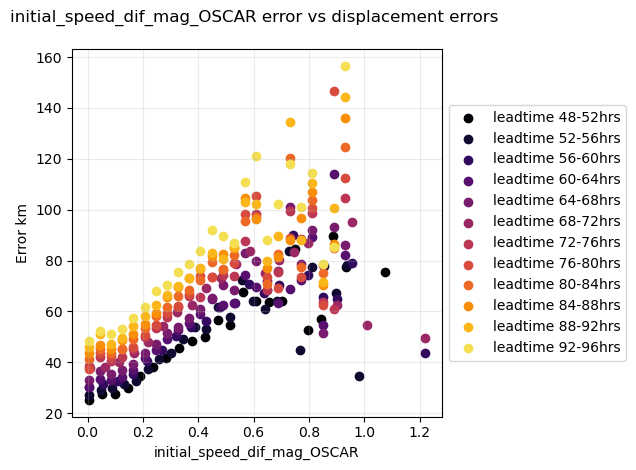

In [248]:
fig, ax = plt.subplots()
cmap = plt.cm.inferno
ofset = 12 ## ofsets in 4 hour incruments 
timerange = 12
variable = "initial_speed_dif_mag_OSCAR"
for i in range(timerange):
    speedbins, binned_errors = Projection_binning(merged,variable, i+ofset)
    ax.scatter(speedbins[binned_errors.index.codes], binned_errors, label=f"leadtime {(i+ofset)*4}-{(i+ofset+1)*4}hrs", color=cmap(i/timerange))
ax.set_ylabel("Error km")
ax.set_xlabel(variable)
#ax.set_xlim(0,1)
#ax.set_ylim(0,60)
ax.set_title(f"{variable} error vs displacement errors \n ")
ax.grid(alpha = 0.25)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()

### initial Speed and angle Corrialtion

Text(0.5, 1.0, 'Mean Error vs Initial Angle and Speed Difference \n Number are amount points in each bin \n Errors at leadtime: 72 hrs')

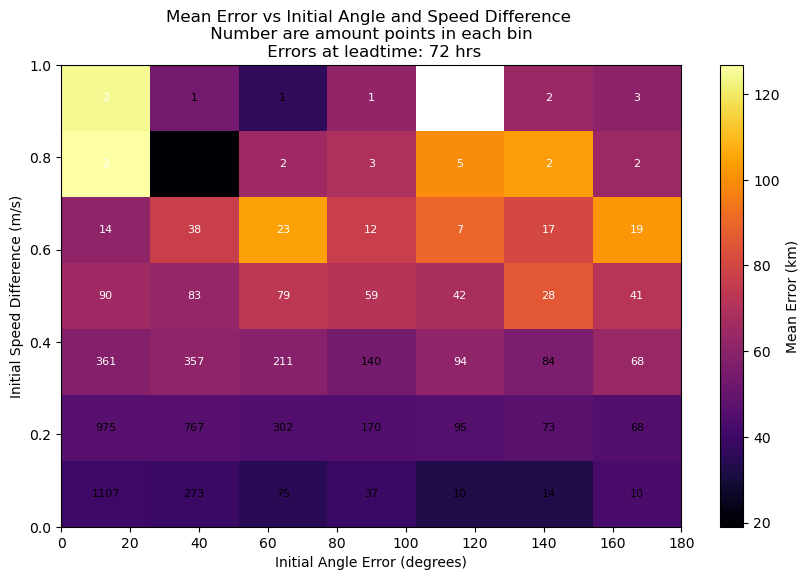

In [258]:
## making a plot of intial angle error and speed error, 
# need to calculate speed error 
# merged.initial_speed is the speed of dFAD at time zero. 

angle_var = "initial_angle_OSCAR"
speed_var = "initial_speed_dif_mag_OSCAR"

merged = merged.sort_values(by = "leadtime")
target_leadtime = 24*3-2
merged_start = merged.query("leadtime > @target_leadtime").drop_duplicates(subset = ["BuoyID", "starttime"])
target_leadtime_upper = target_leadtime + 12
merged_start = merged_start.query("leadtime < @target_leadtime_upper") 

# Create 2D bins for initial_angle and initial_speed_dif_mag
angle_bins = np.linspace(0, 180, 8)
speed_bins = np.linspace(0, 1, 8)

# Bin the data
merged_start["angle_bin"] = pd.cut(merged_start[angle_var], angle_bins)
merged_start["speed_bin"] = pd.cut(merged_start[speed_var], speed_bins)

# Calculate mean error for each 2D bin
binned_data = merged_start.groupby(["angle_bin", "speed_bin"]).agg({"error_km": "mean"}).reset_index()
binned_pivot = binned_data.pivot_table(index="speed_bin", columns="angle_bin", values="error_km")

# Create meshgrid for pcolormesh

angle_mesh, speed_mesh = np.meshgrid(angle_bins, speed_bins)

# Convert binned_pivot to 2D array for pcolormesh
error_values = binned_pivot.values

fig, ax = plt.subplots(figsize=(10, 6))
pcm = ax.pcolormesh(angle_mesh, speed_mesh, error_values, cmap="inferno", shading="auto")
cbar = fig.colorbar(pcm, ax=ax, label="Mean Error (km)")
#pcm.set_clim(10,120)

counts = merged_start.groupby(["angle_bin", "speed_bin"]).size().reset_index(name="count")
counts_pivot = counts.pivot(index="speed_bin", columns="angle_bin", values="count")
count_values = counts_pivot.values
angle_centers = (angle_bins[:-1] + angle_bins[1:]) / 2
speed_centers = (speed_bins[:-1] + speed_bins[1:]) / 2
angle_cent_mesh, speed_cent_mesh = np.meshgrid(angle_centers, speed_centers)
for (i, j), val in np.ndenumerate(count_values):
    cnt = count_values[i, j]
    if np.isnan(cnt):
        continue
    x = angle_cent_mesh[i, j]
    y = speed_cent_mesh[i, j]
    err = error_values[i, j] if not np.isnan(error_values[i, j]) else 0
    text_color = "white" if err > (pcm.get_clim()[1] * 0.45) else "black"
    ax.text(x, y, int(cnt), ha="center", va="center", color=text_color, fontsize=8)
# <-- END INSERTION

ax.set_xlabel("Initial Angle Error (degrees)")
ax.set_ylabel("Initial Speed Difference (m/s)")
ax.set_title(f"Mean Error vs Initial Angle and Speed Difference \n Number are amount points in each bin \n Errors at leadtime: {target_leadtime +2} hrs")

#### removing initial angle varience 

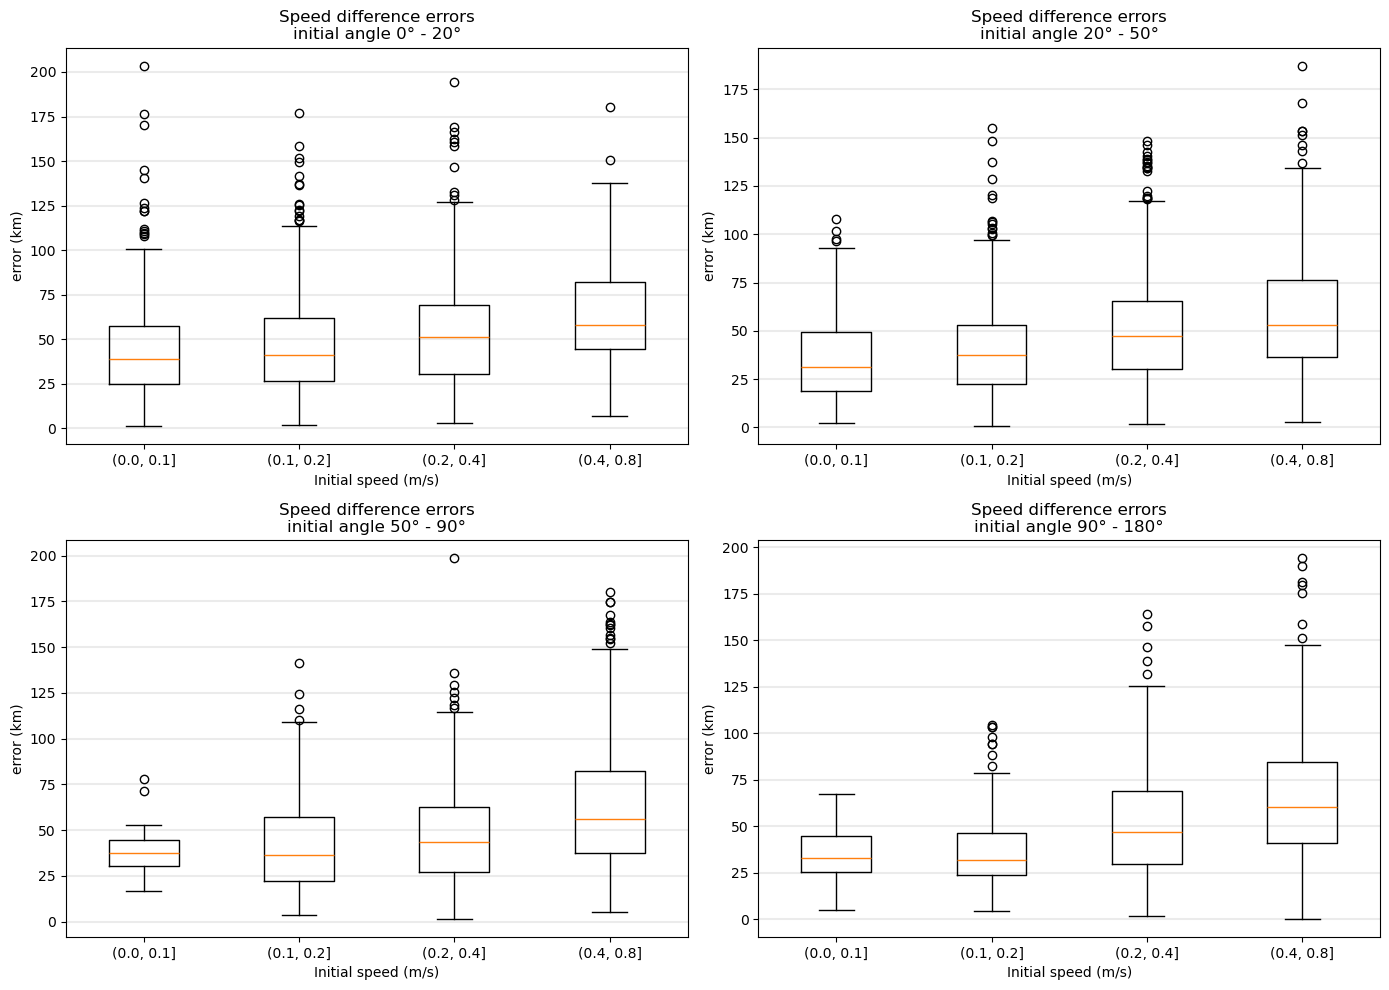

In [259]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
axs = [ax1, ax2, ax3, ax4]

# Define parameters for each subplot
params = [
    {"lowerbound": 0, "higherbound": 20, "ax": ax1},
    {"lowerbound": 20, "higherbound": 50, "ax": ax2},
    {"lowerbound": 50, "higherbound": 90, "ax": ax3},
    {"lowerbound": 90, "higherbound": 180, "ax": ax4},
]

for i, param in enumerate(params):
    lowerbound = param["lowerbound"]
    higherbound = param["higherbound"]
    ax = param["ax"]
    
    angle_slice = merged_start[merged_start.initial_angle > lowerbound]
    angle_slice = angle_slice[angle_slice.initial_angle < higherbound].reset_index(drop=True)
    bins = np.linspace(0, 0.8, 4)
    bins = np.array([0, 0.1, 0.2, 0.4, 0.8])
    angle_slice["speed_bin"] = pd.cut(angle_slice.initial_speed_dif_mag, bins)
    grouped_speed_lists = [group.tolist() for name, group in angle_slice.groupby("speed_bin")["error_km"]]
    bins_list = angle_slice.speed_bin.unique().sort_values()
    
    ax.boxplot(grouped_speed_lists, tick_labels=bins_list[:-1])
    ax.grid(axis="y", alpha=0.25, lw=1.5)
    ax.set_xlabel("Initial speed (m/s)")
    ax.set_ylabel("error (km)")
    ax.set_title(f"Speed difference errors\ninitial angle {lowerbound}° - {higherbound}°")
    # ax.set_ylim(0, 150)

plt.tight_layout()

# lowerbound = 0
# higherbound = 40
# angle_slice = merged_start[merged_start.initial_angle > lowerbound]
# angle_slice = angle_slice[angle_slice.initial_angle < higherbound].reset_index(drop = True)
# bins = np.linspace(0,0.8,4)
# angle_slice["speed_bin"] = pd.cut(angle_slice.initial_speed_dif_mag, bins)
# grouped_speed_lists = [group.tolist() for name, group in angle_slice.groupby("speed_bin")["error_km"]]
# bins_list = angle_slice.speed_bin.unique().sort_values()
# print(len(grouped_speed_lists))
# fig, ax = plt.subplots()
# ax.boxplot(grouped_speed_lists, tick_labels = bins_list[:-1])
# ax.grid(axis = "y", alpha = 0.25, lw = 1.5)
# ax.set_xlabel("Initial speed speed m/s")
# ax.set_ylabel("error km")
# ax.set_title(f"speed differance errors \n with intial angle errors of {lowerbound} - {higherbound}")

#### Removing Initial Speed, Focusing on just inital angle varience. 


4 4
4 4
4 4
4 4


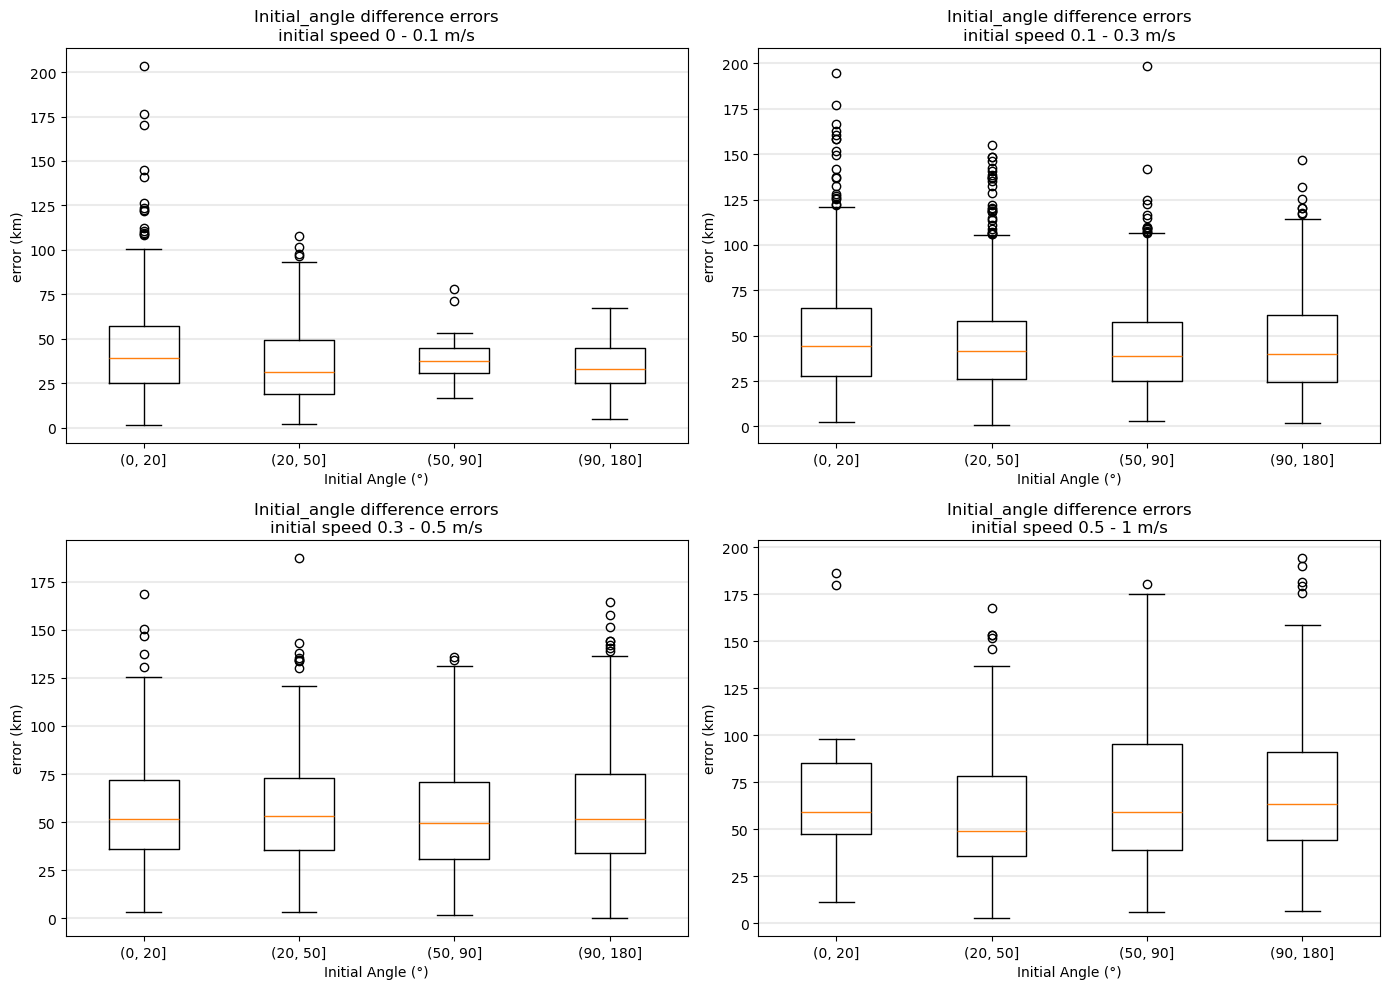

In [260]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
axs = [ax1, ax2, ax3, ax4]

# Define parameters for each subplot
params = [
    {"lowerbound": 0, "higherbound": 0.1, "ax": ax1},
    {"lowerbound": 0.1, "higherbound": 0.3, "ax": ax2},
    {"lowerbound": 0.3, "higherbound": 0.5, "ax": ax3},
    {"lowerbound": 0.5, "higherbound": 1, "ax": ax4},
]

for i, param in enumerate(params):
    lowerbound = param["lowerbound"]
    higherbound = param["higherbound"]
    ax = param["ax"]
    speed_slice = merged_start[merged_start.initial_speed_dif_mag > lowerbound]
    speed_slice = speed_slice[speed_slice.initial_speed_dif_mag < higherbound].reset_index(drop = True)
    bins = np.linspace(0,170,6)
    bins = np.array([0, 20, 50, 90, 180])
    speed_slice["angle_bin"] = pd.cut(speed_slice.initial_angle, bins)
    grouped_angle_lists = [group.tolist() for name, group in speed_slice.groupby("angle_bin")["error_km"]]
    bins_list = speed_slice.angle_bin.unique().sort_values()
    print(len(grouped_angle_lists), len(bins_list))
    ax.boxplot(grouped_angle_lists, tick_labels=bins_list[:])
    ax.grid(axis="y", alpha=0.25, lw=1.5)
    ax.set_xlabel("Initial Angle (°)")
    ax.set_ylabel("error (km)")
    ax.set_title(f"Initial_angle difference errors\ninitial speed {lowerbound} - {higherbound} m/s")
    #ax.set_ylim(0, 150)
fig.tight_layout()

#### Developing a better analysis between initial angle error and initial speed difference 

1) split into meaningful quadrents. 
    - quadrents should include a statistically significant amount of data. 
        - quaderrents areas do not have to be the same size 
        -   width and high and quadrent do not need to be the same size also
            - size needs to be showuing error differances greater than bootstapping distributions. satistically significnat in each direction of the axis. 
            so we can confidently say that moving in one direction has a diffent error. 
    - could do boot strapping to show uncertainties because of forecasts generated. 
2) within each quadrent generate the expected error spreads. 
3) 

In [ ]:
## checking making thing the initial 

merged_leadtime = merged.query("leadtime == 0 ")
# print(merged_leadtime[["initial_speed_dif_mag", "BuoyID"]].sort_index().head(40))
# print(merged_start[["initial_speed_dif_mag", "BuoyID"]].sort_index().head(20))
grouped = merged.groupby(["BuoyID", "starttime"])

# Method 1: Get a specific group by name (tuple of group keys)
first_group_name = ('ISD+496035', pd.Timestamp('2024-11-07 00:01:00'))
first_group = grouped.get_group(first_group_name)

# Method 2: Iterate and get the nth group
n = 0  # Get first group (0-indexed)
for i, (name, group) in enumerate(grouped):
    if i == n:
        first_group = group
        first_group_name = name
        break

# Method 3: Convert to list of groups (use with caution on large datasets)
groups_list = [group for name, group in grouped]
first_group = groups_list[10]
first_group

,Unnamed: 0,BuoyID,Time,lat_true,lon_true,lat_forcast,lon_forcast,leadtime,error_km,lats,...,angle,initial_angle,initial_projection,projection_OSCAR,angle_OSCAR,initial_angle_OSCAR,initial_projection_OSCAR,lead_bins,speed_dif_mag,initial_speed_dif_mag
223377,0,ISD+496040,2024-12-03 03:42:00,5.22988,-160.98070,NaN,NaN,0.000000,NaN,5.22988,...,63.366379,63.366379,0.217688,0.471695,19.293885,19.293885,0.471695,NaN,0.448930,0.44893
223502,1,ISD+496040,2024-12-03 07:42:00,5.27408,-160.93570,5.282417,-160.997348,4.000000,6.888540,5.27408,...,68.944902,63.366379,0.217688,0.426025,25.043063,19.293885,0.471695,"(0.0, 4.0]",0.536246,0.44893
223624,2,ISD+496040,2024-12-03 11:42:00,5.31215,-160.88925,5.332894,-161.007077,8.000000,13.247626,5.31215,...,76.058604,63.366379,0.217688,0.367965,31.197235,19.293885,0.471695,"(4.0, 8.0]",0.561437,0.44893
223744,3,ISD+496040,2024-12-03 15:43:00,5.34098,-160.84148,5.380378,-161.008128,12.016667,18.962401,5.34098,...,86.757168,63.366379,0.217688,0.304068,39.849861,19.293885,0.471695,"(12.0, 16.0]",0.593493,0.44893
223865,4,ISD+496040,2024-12-03 19:45:00,5.38520,-160.78440,5.425141,-161.000024,16.050000,24.279378,5.38520,...,81.611675,63.366379,0.217688,0.313225,31.623988,19.293885,0.471695,"(16.0, 20.0]",0.631001,0.44893
223964,5,ISD+496040,2024-12-03 23:41:00,5.43168,-160.72497,5.465689,-160.986625,19.983333,29.209100,5.43168,...,82.090368,63.366379,0.217688,0.308294,27.934980,19.293885,0.471695,"(16.0, 20.0]",0.655878,0.44893
224103,6,ISD+496040,2024-12-04 03:42:00,5.46245,-160.67027,5.504343,-160.968793,24.000000,33.369081,5.46245,...,88.436785,63.366379,0.217688,0.307884,32.629310,19.293885,0.471695,"(20.0, 24.0]",0.620824,0.44893


In [ ]:
## remove duplicate forecasts
def add_inital_time(ds:pd.DataFrame):
    """adds intial time of forecast (time - leadtime) and changes collumns to pd.DateTime objects"""
    ds["Time"] = pd.to_datetime(ds["Time"])
    ds["initial_time"] =  ds["Time"] - pd.to_timedelta(ds["leadtime"], unit = "hours")
    ds["initial_time"] = ds["initial_time"].dt.round(freq = "min")
    return ds
merged = add_inital_time(merged)
merged_clean = merged.drop_duplicates(subset=['BuoyID', 'initial_time', 'leadtime'], keep='first')

: 

: 

8429

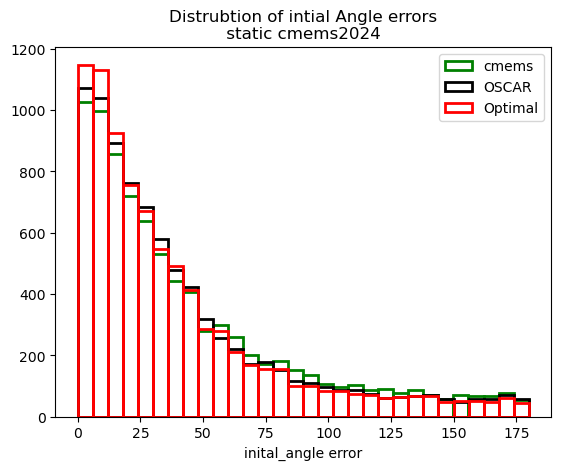

: 

: 

In [ ]:
### distribution of inittial error speeds. 
initial_speeds = merged_clean.query("leadtime == 0")
initial_speeds_opt = fc_opt.query("leadtime == 0")
Greater90 = initial_speeds.query("initial_angle > 90")["initial_angle"].count()
fig, ax =plt.subplots()
ax.hist(initial_speeds.initial_angle, 30, fill= None, edgecolor = "g", lw =2, label = "cmems")
ax.hist(initial_speeds.initial_angle_OSCAR, 30, fill= None, edgecolor = "k", lw = 2, label = "OSCAR")
ax.hist(initial_speeds_opt.initial_angle, 30, fill= None, edgecolor = "r", lw = 2, label = "Optimal")
ax.set_xlabel("inital_angle error")
ax.set_title("Distrubtion of intial Angle errors\n static cmems2024 ")
ax.legend()
Greater90/initial_speeds.initial_angle.count()
initial_speeds.shape[0]
initial_speeds_opt.shape[0]

In [ ]:
## checking number of forecasts 
print(initial_speeds.shape, initial_speeds_opt.shape)

(8429, 28) (8429, 23)


: 

: 

### Time Series of Errors 

In [ ]:

bins = np.linspace(0,8*24,2*24+1)
fc["lead_bins"] = pd.cut(merged["leadtime"], bins)
binlist = fc["lead_bins"].unique()

def Forecast_timeseries(ds:pd.DataFrame, window:int, bin)-> pd.DataFrame:
    bins = np.linspace(0,8*24,2*24+1)
    ds["lead_bins"] = pd.cut(ds["leadtime"], bins)
    # (24.0, 28.0]
    fc_grouped = ds.groupby("lead_bins")
    fc24 = fc_grouped.get_group(a)
    fc24["Day"] = fc24.Time.dt.date
    ts24 = fc24.groupby("Day")["error_km"].mean()
    ts24 = ts24.to_frame("error_km").reset_index(drop= False)
    ts24["rolling"] = ts24["error_km"].rolling(window).mean()
    return ts24

: 

: 

In [ ]:
window = 7
a = binlist[18]
print(a)
fcts = Forecast_timeseries(fc, window , a)
fcts2 = Forecast_timeseries(fc2,window, a)
fcts3 = Forecast_timeseries(fc3, window, a)

(68.0, 72.0]


: 

: 

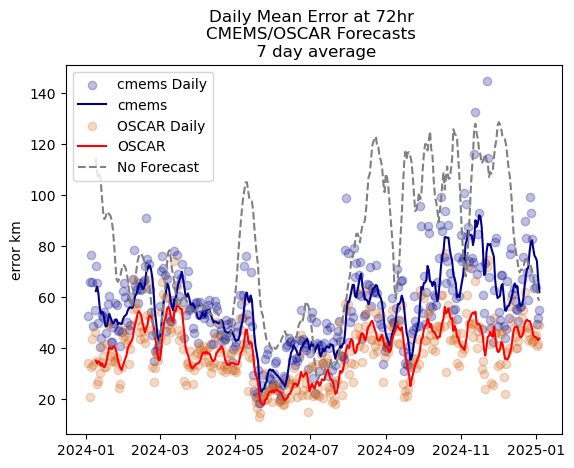

: 

: 

In [ ]:
fig, ax = plt.subplots()
#CMEMS
ax.scatter(fcts.Day, fcts.error_km, color = "darkblue", alpha = 0.25, label = "cmems Daily")
ax.plot(fcts.Day, fcts["rolling"], color = "darkblue", label = "cmems")
#OSCAR 
ax.scatter(fcts2.Day, fcts2.error_km, color = "chocolate", alpha = 0.25 ,label = "OSCAR Daily")
ax.plot(fcts2.Day, fcts2["rolling"], color = "red", label = "OSCAR")
#NO Forecast
#ax.scatter(fcts3.Day, fcts3.error_km, color = "g", alpha = 0.25 ,label = "OSCAR Daily")
ax.plot(fcts3.Day, fcts3["rolling"], color = "gray", label = "No Forecast", linestyle = "--")
ax.set_title("Daily Mean Error at 72hr \nCMEMS/OSCAR Forecasts \n 7 day average")
ax.set_ylabel("error km")
ax.legend()

Text(0.5, 1.0, 'mean daily speed \n cmems2024')

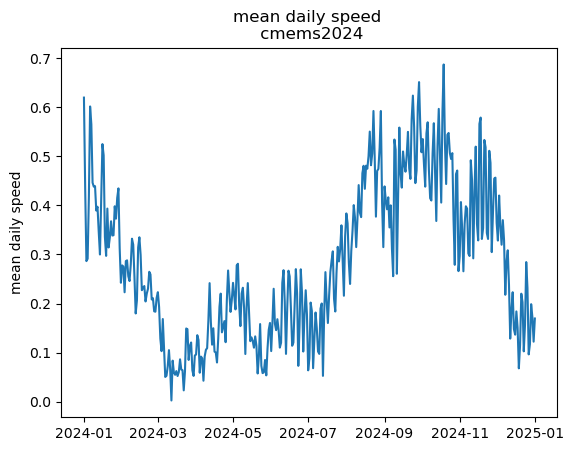

: 

: 

In [ ]:
import xarray as xr 
cmems =xr.open_dataset(r"Data\cmems.nc")
cmems = cmems.sel(time = slice("2024-01-01", "2025-01-01"), depth = 15.81007  )
fig, ax = plt.subplots()
speed = np.sqrt(cmems.uo.mean(dim = ["latitude", "longitude"])**2 + cmems.vo.mean(dim = ["latitude", "longitude"])**2)
ax.plot(cmems.time, speed)
ax.set_ylabel("mean daily speed")
ax.set_title("mean daily speed \n cmems2024")

### Creating forecast based off of initial error

In [ ]:
oscar_merged = merge_forecast_true(fc1, longlist)
cmems_merged = merge_forecast_true(fc, longlist)
##remove duplicate forecasts start at the same time 
cmems_merged["starttime"] = cmems_merged['Time']- pd.to_timedelta(cmems_merged["leadtime"],unit = "hours").dt.round("min")
oscar_merged["starttime"] = oscar_merged['Time']- pd.to_timedelta(oscar_merged["leadtime"], unit="hours").dt.round("min")

## calcuate inital angle for both
oscar_merged = calc_projection_initial_angle(oscar_merged, "_OSCAR")
cmems_merged = calc_projection_initial_angle(cmems_merged)
oscar_merged = calc_projection_initial_angle(oscar_merged)
cmems_merged = calc_projection_initial_angle(cmems_merged, "_OSCAR")
oscar_merged = calc_intial_speed_dif(oscar_merged, "_OSCAR")
cmems_merged = calc_intial_speed_dif(cmems_merged)
oscar_merged = calc_intial_speed_dif(oscar_merged)
cmems_merged = calc_intial_speed_dif(cmems_merged, "_OSCAR")


: 

: 

In [ ]:
## For each forecast decide which one is better based off of initial angle. 
def lower_initial_angle(group):
    if group.empty:
        return group

    idx = group["leadtime"].idxmin()
    cmemsi = group.at[idx, "initial_angle"] 
    oscari = group.at[idx, "initial_angle_OSCAR"] 

    choice = "cmems" if cmemsi < oscari else "OSCAR"

    g = group.copy()
    g["best_model"] = choice
    return g

def lower_porjection_angle(group):
    if group.empty:
        return group
    
    idx = group["leadtime"].idxmin()
    cmemsi = group.at[idx, "projection"]
    oscari = group.at[idx, "projection_OSCAR"]

    if oscari < 0 and (cmemsi > oscari): 
        choice = "cmems"
    else: 
        choice = "OSCAR"
    g = group.copy()
    g["best_model"] = choice
    return g

def lower_speed_dif(group):
    if group.empty:
        return group
    
    idx = group["leadtime"].idxmin()
    cmemsi = group.at[idx, "initial_speed_dif_mag"]
    oscari = group.at[idx, "initial_speed_dif_mag_OSCAR"]

    choice = "cmems" if cmemsi < oscari else "OSCAR"

    g = group.copy()
    g["best_model"] = choice
    return g


cmems_grouped = cmems_merged.groupby(["BuoyID", "starttime"]).apply(lower_speed_dif)
OSCAR_grouped = oscar_merged.groupby(["BuoyID", "starttime"]).apply(lower_speed_dif)
#cmems_grouped.reset_index().query("leadtime == 0").query("best_model == 'OSCAR'").shape[0]

cmems_forecasts = cmems_grouped.reset_index().query("best_model == 'cmems'")
oscar_forecasts = OSCAR_grouped.reset_index().query("best_model == 'OSCAR'")
oscar_forecasts["initial_angle_used"] = oscar_forecasts["initial_angle_OSCAR"]
cmems_forecasts["initial_angle_used"] = cmems_forecasts["initial_angle"]
oscar_forecasts["projection_used"] = oscar_forecasts["projection_OSCAR"]
cmems_forecasts["projection_used"] = cmems_forecasts["projection"]

ia_forecast = pd.concat([oscar_forecasts,cmems_forecasts])

: 

: 

In [ ]:
### now want to compair to the optimal forecasting method and see how many we have gotten right( picked cmems or oscar correctly) 

fc_opt = merge_forecast_true(fc2, longlist)
fc_opt = add_starttime(fc_opt)
# get unique groups as a dataframe
grouped_opt = fc_opt[["BuoyID", "starttime", "model"]].drop_duplicates().reset_index(drop=True)
grouped_ia = ia_forecast[["BuoyID", "starttime", "best_model"]].drop_duplicates().reset_index(drop =True) 
print(len(grouped_ia), len(grouped_opt))
# Find groups that appear in both dataframes
merged_groups = pd.merge(grouped_ia, grouped_opt, on=['BuoyID', 'starttime'], how='inner')
common_groups = merged_groups[['BuoyID', 'starttime']].drop_duplicates()
print(f"Number of groups in both: {len(common_groups)}")


8429 8429
Number of groups in both: 8429


: 

: 

In [ ]:
#compair two comulms of the data set and produce a new column with 1 being the values in that row  are the same and 
merged_groups["correct"] = (merged_groups["best_model"] == merged_groups["model"]).astype(int)
corect_forecasts = merged_groups[ merged_groups.correct == 1]
incorrect_forecasts = merged_groups[merged_groups.correct != 1]
print(f"Percent of correct model chosen {corect_forecasts.shape[0]/merged_groups.shape[0]}")
print(f"percent cmems {len(grouped_ia[grouped_ia.best_model == 'cmems'])/len(grouped_ia)} ")

Percent of correct model chosen 0.6315102621900581
percent cmems 0.4483331356032744 


: 

: 

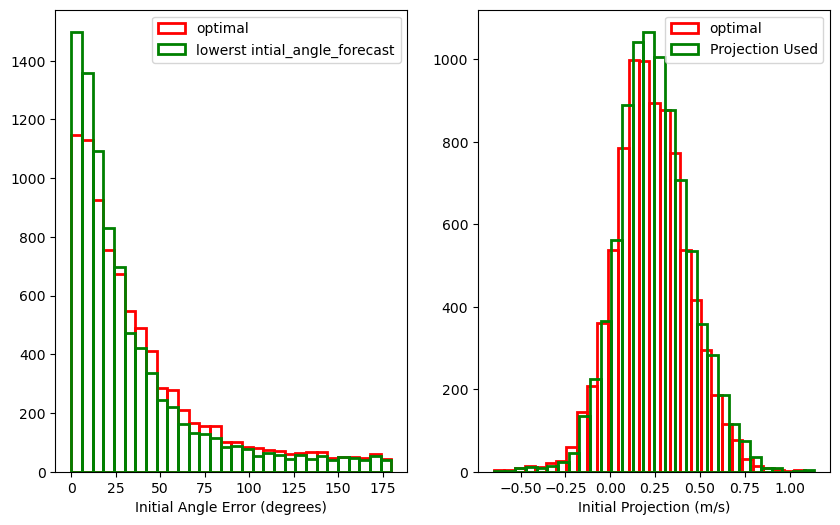

: 

: 

In [ ]:
## hsitorgram like above of distribution of intial angle errors. 
fc_optia = fc_opt_saved.copy()
fc_optia = fc_optia.query("leadtime == 0")
intial_times_ia = ia_forecast.query("leadtime == 0")
fig, ax = plt.subplots(1,2, figsize = (10,6))
ax[0].hist(fc_optia.initial_angle, 30, fill= None, edgecolor = "r", lw =2, label = "optimal")
ax[0].hist(intial_times_ia.initial_angle_used, 30, fill= None, edgecolor = "g", lw =2, label = "lowerst intial_angle_forecast")
ax[0].set_xlabel("Initial Angle Error (degrees)")
ax[0].legend()
ax[1].hist(fc_optia.projection, 30, fill= None, edgecolor = "r", lw =2, label = "optimal")
ax[1].hist(intial_times_ia.projection_used, 30, fill= None, edgecolor = "g", lw =2, label = "Projection Used")
ax[1].set_xlabel("Initial Projection (m/s)")
ax[1].legend()

In [ ]:
### saving initial angle forecasts 
ia_save = ia_forecast[["BuoyID", "Time", "lat_true", "lon_true", "lon_forcast", "lat_forcast", "leadtime", "best_model", "initial_angle_used"]]
ia_save.to_csv(r"Parcels\saved_output\intial_speed_dif.csv")

: 

: 

In [ ]:
ia_forecast_less90 = ia_forecast[ia_forecast["initial_angle_used"] < 90]
ia_forecast_less90.to_csv("Parcels\saved_output\initial_angle_forecasts_less90.csv")

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_18440\2265086388.py:2: SyntaxWarning: invalid escape sequence '\s'
  ia_forecast_less90.to_csv("Parcels\saved_output\initial_angle_forecasts_less90.csv")


: 

: 